In this notebook, we try to solve the one norm problem with cost function 

\begin{equation}
    J(u) = \|Ru - y\|_2^2 + \alpha \|u\|_1
\end{equation}

by rewriting it into a least squares problem and using normal equations to solve the leastsquares problem. In each iteration, the least squares problem is

\begin{equation*}
    u_{k+1} = \arg\min_u \left\| \begin{bmatrix}
        R\\
        \sqrt{\alpha} W^{1/2}_k
    \end{bmatrix}u - \begin{bmatrix}
        y\\
        0
    \end{bmatrix}\right\|_2^2
\end{equation*}

with $W_k = \text{diag}\{u^{-1}_k\}$

The minimiser is given as 

\begin{equation}
    (R^TR + \alpha W_k)^{-1}R^Ty = u_{k+1}
\end{equation}

In [1]:
# import necessary packages

# CIL imports
from cil.framework import ImageGeometry, AcquisitionGeometry, BlockDataContainer, ImageData

# From cil.plugins import TomoPhantom
from phantominator import shepp_logan

from cil.optimisation.functions import LeastSquares, L2NormSquared

# For display
from cil.utilities.display import show2D, show1D, show_geometry

# ASTRA imports
from cil.plugins.astra.operators import ProjectionOperator

from cil.optimisation.algorithms import CGLS, GD

# External imports
import numpy as np
import matplotlib.pyplot as plt
import logging

from cil.optimisation.operators import BlockOperator, DiagonalOperator, CompositionOperator

import scipy as sp

In [2]:
# setting pixels and angles
n_pixels = 256
n_angles = 50

## Setting up CT problem

In [3]:
# Set logging level for CIL processors:
logging.basicConfig(level=logging.WARNING)
cil_log_level = logging.getLogger('cil.processors')
cil_log_level.setLevel(logging.INFO)

# Setting background defaults
cmap = "rainbow"
device = "cpu"

In [4]:
def add_poss_noise(background_counts, n_angles, n_pixels):
    A, sino, ig, ag, phantom = get_A(n_angles, n_pixels)

    # adding noise to the sinogram

    # Convert the simulated absorption sinogram to transmission values using Lambert-Beer. 
    counts_poss = background_counts * np.exp(-sino.as_array())

    # Use as a mean for Poisson data generation.
    noisy_counts_poss = np.random.poisson(counts_poss)
    nonzero = noisy_counts_poss > 0

    # Convert back to absorption sinogram.
    sino_out_poss = np.zeros_like(sino.as_array())
    sino_out_poss[nonzero] = -np.log(noisy_counts_poss[nonzero]/ background_counts)

    # allocate sino_noisy and fill with noisy data
    sino_noisy_poss = ag.allocate()
    sino_noisy_poss.fill(sino_out_poss)

    return sino_noisy_poss

def get_A(n_angles, n_pixels):

    # Angles
    angles = np.linspace(0, 180, n_angles, endpoint=False, dtype=np.float32)

    # Setup acquisition geometry

    # Note that if number of pixels and number of angels are equal, 
    # the matrix is square and an exact solution can be found, 
    # then there is a sufficient number of pojections
    ag = AcquisitionGeometry.create_Parallel2D()\
                                .set_angles(angles)\
                                .set_panel(n_pixels, pixel_size=1/n_pixels)

    # Setup image geometry
    ig = ImageGeometry(voxel_num_x=n_pixels, 
                    voxel_num_y=n_pixels, 
                    voxel_size_x=1/n_pixels, 
                    voxel_size_y=1/n_pixels)
    
    A = ProjectionOperator(ig, ag, device='cpu')

    # Get phantom
    phantom = ImageData(np.flip(shepp_logan(n_pixels)), geometry = ig)

    # Create an acquisition data (numerically)
    sino = A.direct(phantom)

    return A, sino, ig, ag, phantom

## IRN for lasso regularisation with manually implemented CG

In [42]:
def apply_operator_onenorm(x, W, R, alpha):

    """
    Applies the operator 
    
    R^TR + alpha * W 
    
    to the input ImageData x. Used to solve the normal equations 

    (R^TR + alpha * W_k)u = R^Ty

    with W_k = u_k**(-1)

    Input:
        x:  ImageData to which the operator is applied
        W:  Weights
        alpha:  regularisation parameter

    Output:
        z: ImageData (R^TR + alpha * W)x
    """
    
    # z2 = (R^TR)x
    z1 = R.direct(x)
    z2 = R.adjoint(z1)

    # z3 = Wx
    w_operator = DiagonalOperator(W)
    z3 = w_operator.direct(x)

    z = z2 + alpha * z3

    return z

def CG(initial, max_iter, R, RTy, alpha, Wk, cg_tol, apply_operator):

    """
    Solves for u in the system 

    apply_operator(u) = R^Ty (*)

    using Conjugate Gradient (CG)

    INPUT:
        initial:    Inital guess for u (ImageData)
        max_iter:   Maximum number of cg iterations (float)
        R:          ProjectionOperator necessary for 'apply_operator' function
        RTb:        R^Tb (ImageData)
        alpha:      Regularisation parameter (float)
        Wk:         Weights in the kth iteration, necessary for `apply_operator' function (ImageData)
        cg_tol:     Tolerance on CG (float)
        apply_operator: Function that applies matrix from normal equation
    
    OUTPUT:
        uj:         Minimiser of (*) (ImageData)
        conv_arr:   Array with residuals from each iteration (numpy array)
        inner_iter_count:   Number of inner iterations used (float)
    """

    u0 = initial.copy()
    r0 = RTy - apply_operator(x=u0, W=Wk, R=R, alpha=alpha)
    p0 = r0
    
    # set initials, note these are all of class <ImageData> 
    pj = p0
    uj = u0
    rj = r0
    delta_new = rj.dot(rj.conjugate())

    # needed for stopping criteria later
    norm = L2NormSquared()
    r0_norm = norm(r0)
    rel_tol = r0_norm * cg_tol

    # to check convergence
    conv_arr = []
    conv_arr.append(r0_norm)

    # counting inner iterations
    inner_iter_count = max_iter

    # perform CG iterations
    for j in range(max_iter):

        # zk = Rpk
        zj = apply_operator(x=pj, W=Wk, R=R, alpha=alpha)

        tau_j = delta_new/(pj.dot(zj.conjugate()))
        
        uj_plus_one = uj + tau_j * pj 
        rj_plus_one = rj - tau_j * zj

        delta_old = delta_new
        delta_new = rj_plus_one.dot(rj_plus_one.conjugate())

        beta_j = delta_new/delta_old

        pj_plus_one = rj_plus_one + beta_j * pj

        # stopping criteria
        check = norm(rj_plus_one)
        conv_arr.append(check)
        if check < rel_tol:
            uj = uj_plus_one
            inner_iter_count = j + 1
            print(f"cg converged in {j+1} iterations")
            break

        # reset variables
        rj = rj_plus_one
        pj = pj_plus_one
        uj = uj_plus_one

    return uj, conv_arr, inner_iter_count


def onenorm_normal(initial, inner_iter, outer_iter, R, sino, alpha, er, cg_tol, exact):
    """
    Finds a solution for the problem 

    ||Ru - y||_2^2 + alpha * ||u||_1

    by first rewriting the regularisation term into a two norm by a weights matrix W and then solving via
    the normal equations using CG. The normal equations are given by 

    (R^TR + alpha*W_k)u = R^Ty

    In each outer iterations the matrix W_k is updated (reweighted), W_k = u_k^(-1)

    Input:
        initial:    Initial guess for u (ImageData)
        inner_iter: Number of CG iterations (scalar)
        outer_iter: Number of outer iterations (scalar)
        R:          The acting operator (Operator)
        sino:       The obtained data (AcquisitionData)
        alpha:      Regularization parameter (scalar)
        er:         Upper bound for 'small values' in W_k that will be set to zero (float)

    Output:
        uk:         Reconstructed image (ImageData)
    """

    # setting up LHS of normal equation
    lhs = R.adjoint(sino)

    # setting initials
    uk = initial.copy()
    get_ig = R.domain_geometry()

    norm = L2NormSquared()
    norm_b = norm(sino)
    err = []

    inner_itercount_arr = []

    if exact == None:
        err_temp = norm(R.direct(uk) - sino) / norm_b
        err.append(err_temp)
    else:
        err_temp = norm(uk - exact)
        err.append(err_temp)

    if er is None:
        er_use = 0.01 * sino.max()
    else:
        er_use = er

    for k in range(outer_iter):

        print(f"outer iteration: {k+1}")
        
        ## reweight the regularisation term ##
        uk_grad = uk.abs()
        uk_grad_np = uk_grad.as_array()

        # distinguish 'large' values from 'small' values
        large_values = uk_grad > er_use # ImageData boolean array

        # reweight large values
        uk_reweighted_np = np.zeros_like(uk.as_array()) # small terms are automatically put to zero
        uk_reweighted_np[large_values] = 2*(uk_grad_np[large_values] ** (-1))

        # convert back to ImageData
        uk_reweighted = get_ig.allocate()   
        uk_reweighted.fill(uk_reweighted_np)

        # performing CG
        cg_output, conv_arr, inner_iter_count = CG(uk, inner_iter, R, lhs, alpha, uk_reweighted, cg_tol, apply_operator_onenorm)
        inner_itercount_arr.append(inner_iter_count)

        uk = cg_output
        Ruk_min_sino = R.direct(uk) - sino

        if exact == None:
            err_temp = norm(Ruk_min_sino) / norm_b
            err.append(err_temp)
        else:
            err_temp = norm(uk - exact)
            err.append(err_temp)

        if er is None:
            e = (Ruk_min_sino).abs()
            er_use = 0.01 * e.max()
        else:
            er_use = er

    return uk, err, conv_arr, inner_itercount_arr

## Results

c:\Users\femke\anaconda3\envs\cil_demos_cpu\Lib\site-packages\cil\framework\data_container.py:112: UserWarning: Over-riding geometry.dtype with data.dtype
  warnings.warn("Over-riding geometry.dtype with data.dtype", UserWarning)


outer iteration: 1
outer iteration: 2
outer iteration: 3
outer iteration: 4
outer iteration: 5
time for lasso cg: 3.1743884086608887


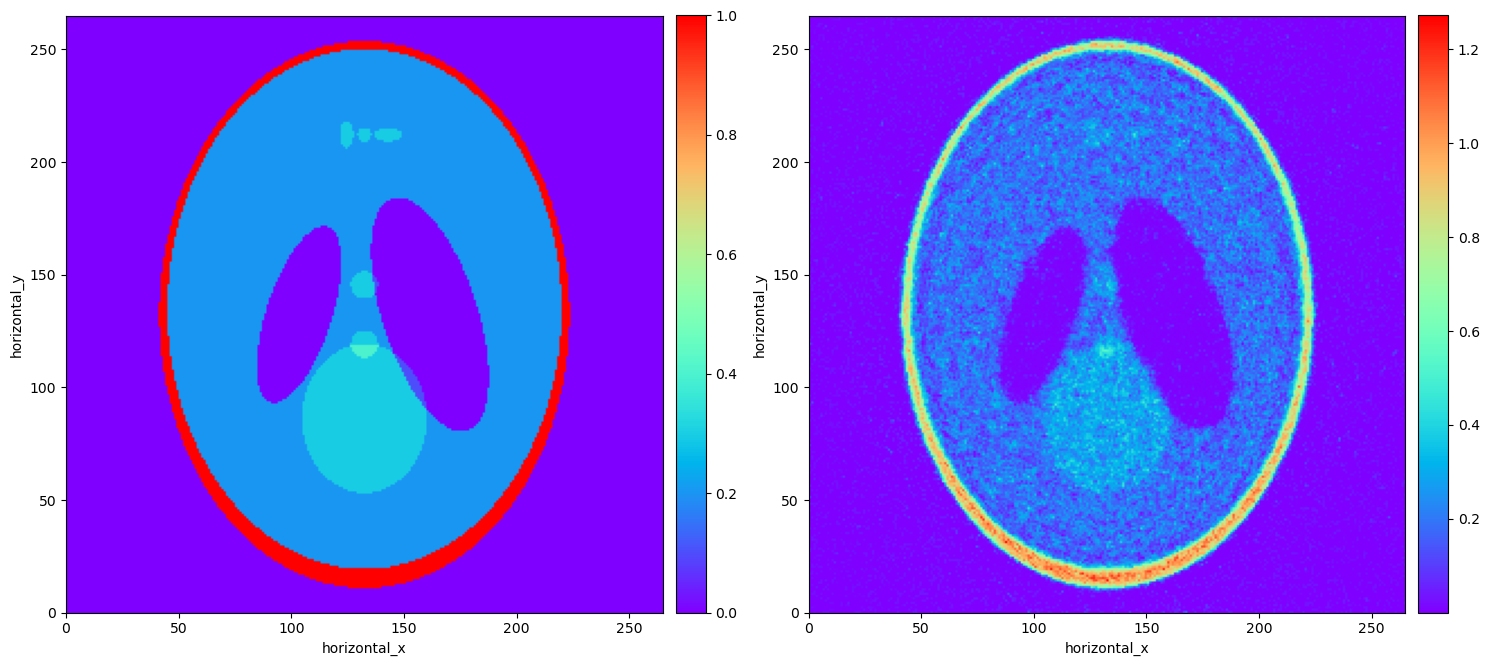

In [44]:
import time
n_pixels = 265
n_angles = 50
sino_noise = add_poss_noise(20000, n_angles, n_pixels)
R, sino, ig, ag, phantom = get_A(n_angles=50, n_pixels=265)

tstart = time.time()
lasso_cg, lasso_cg_error, lasso_cg_convarr, lasso_cg_inneriterations = onenorm_normal(initial = ig.allocate(0), 
                                                                                      inner_iter = 10, 
                                                                                      outer_iter = 5, 
                                                                                      R = R, 
                                                                                      sino = sino_noise, 
                                                                                      alpha = 0.0008, 
                                                                                      er = None, 
                                                                                      cg_tol = 2e-6, 
                                                                                      exact = phantom)
tend = time.time()
print("time for lasso cg:", tend - tstart)

show2D([phantom, lasso_cg.abs()], cmap = 'rainbow')

<>:11: SyntaxWarning: invalid escape sequence '\|'
<>:11: SyntaxWarning: invalid escape sequence '\|'
C:\Users\femke\AppData\Local\Temp\ipykernel_9176\2928575098.py:11: SyntaxWarning: invalid escape sequence '\|'
  plt.ylabel('$\|u_{exact} - u\|_2^2$')


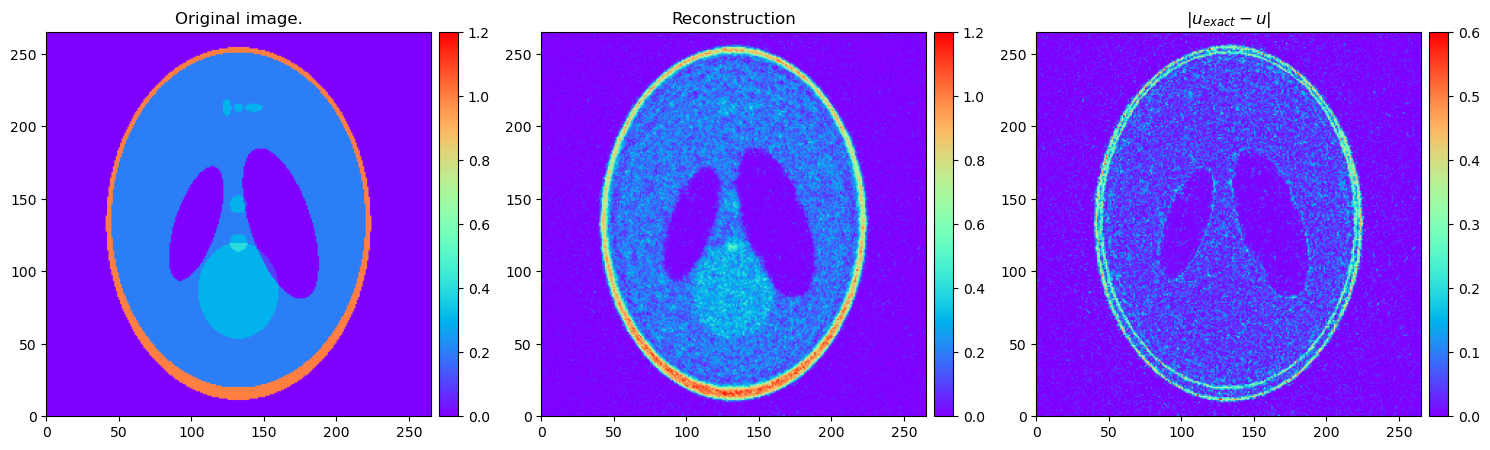

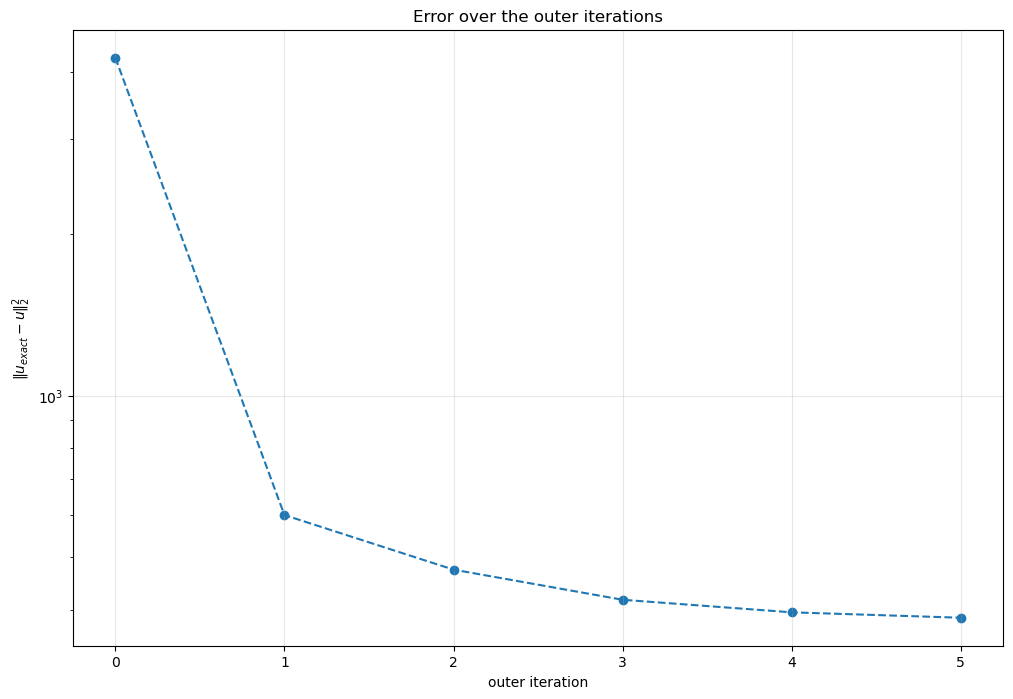

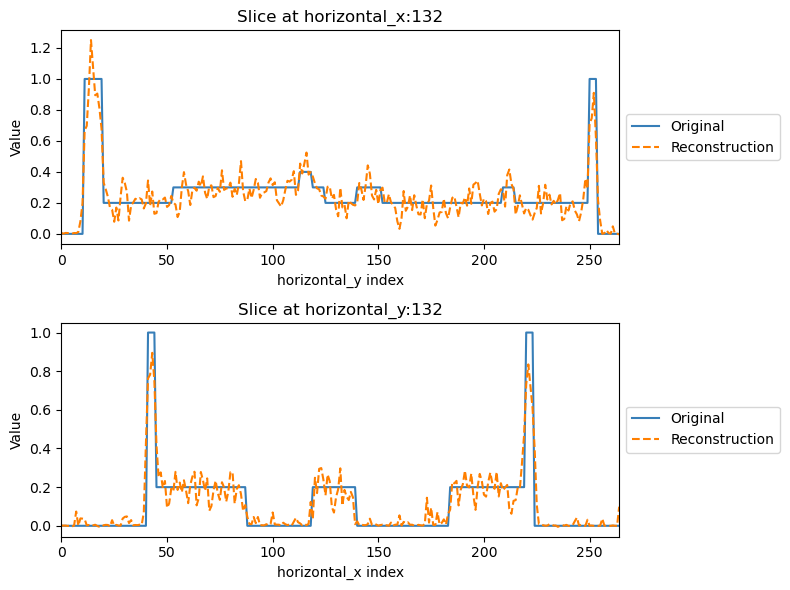

In [45]:
show2D([phantom, lasso_cg.abs(), (phantom-lasso_cg).abs()], ['Original image.', 'Reconstruction', '$|u_{exact} - u|$'], 
       num_cols=3,
       cmap='rainbow', 
       axis_labels=('', ''), 
       fix_range=[(0,1.2), (0,1.2),(0,0.6)])
x = np.linspace(0,len(lasso_cg_error) - 1, len(lasso_cg_error))

plt.figure(figsize=(12,8))
plt.title("Error over the outer iterations")
plt.semilogy(x, lasso_cg_error, linestyle='--')
plt.ylabel('$\|u_{exact} - u\|_2^2$')
plt.xlabel('outer iteration')
plt.scatter(x,lasso_cg_error)
plt.grid(alpha=0.3)

show1D([phantom, lasso_cg], dataset_labels=['Original', 'Reconstruction'])